<center><h1>REPORT 1</h1></center> 

## Aim

### To estimate the dynamical mass of galaxy cluster

## Introduction and Theory

Galaxy clusters are the largest gravitationally bound structures in the universe, containing hundreds to thousands of galaxies,
hot gas, and large amounts of dark matter. Measuring the total mass of these clusters is crucial for understanding their 
structures formation and also cosmological models. One method of estimating the total mass is by observing how galaxies move
within the cluster.The faster motions means stronger gravitational pull, and hence, more mass. This method yields what is known as 
the dynamical mass, which includes both visible and invisible (dark) matter.

To calculate the Dynamical mass, we use a formula derived from virial theorem which relates the kinetic energy of 
galaxies to the gravitational potential of the cluster.
(reference from https://ned.ipac.caltech.edu/level5/Faber/Faber7_1.html#:~:text=Once%20RVT%20has%20been,V2%20RVT%20%2F%20G)

    
$$
M_{\text{dyn}} = \frac{3 \sigma^2 R}{G}
$$


Where:
- $ \sigma $ is the **velocity dispersion** in m/s (`disp * 1000`)
- $ R $ is the **cluster radius** in meters (half the physical diameter converted to meters)
- $ G $ is the **gravitational constant** in SI units


To calculate them we need to things which is velocity dispersion and cluster radius.


Now velocity dispersion is the  velocity dispersion (σ) is the statistical dispersion of 
velocities about the mean velocity for a group of astronomical objects or we can say the standard deviation of velocity.
We can find the velocity of the galaxy by their redshifts(which happens when Light from these galaxies is
shifted to longer (and this means redder) wavelengths when it moves away from us). 

Then about cluster radius, The radius is estimated by converting the maximum angular separation(0) of galaxies(why maximum? It is because maximum 
angular separation gives the the angular distance of each galaxy from the cluster center and we need the galaxy that is farthest from the center
in projection and that galaxy would tell us about the size of the cluster.)
(in arcminutes) into physical diameter(D) using the angular diameter(D_A)distance derived from the cluster’s mean redshift(z).
Formula that are used:
  $$
  r = \frac{cz}{H_0} \left(1 - \frac{z}{2}(1 + q_0)\right)
  $$
  where $q_0$ is the deceleration parameter

  $$
  D_A = \frac{r}{1 + z}
  $$

  $$
  \text{diameter (in Mpc)} = D_A \cdot \theta
  $$    
    

## Code and Analysis

### Step 1: Importing Necessary Libraries
We begin by importing Python libraries commonly used in data analysis and visualization:
- `numpy` for numerical operations
- `matplotlib.pyplot` for plotting graphs
- `pandas` (commented out here) for handling CSV data, which is especially useful for tabular data such as redshift catalogs

> Tip: If you haven’t used `pandas` before, it’s worth learning as it offers powerful tools to manipulate and analyze structured datasets.


For reading big csv files, one can use numpy as well as something called "pandas". We suggest to read pandas for CSV file reading and use that

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.constants import G, c
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u


Before we begin calculations, we define key physical constants used throughout:

- $ H_0 $: Hubble constant, describes the expansion rate of the Universe.
- $c$ : Speed of light.
-  $G$: Gravitational constant.
- $q_0$ : Deceleration parameter, used for approximate co-moving distance calculations.

We will use **`astropy.constants`** to ensure unit consistency and precision.

In [12]:
# Constants:

H_0 = cosmo.H0.value  # Hubble constant in (km/s)/Mpc
c = c.value  # Speed of light in m/s
G = G.to(u.pc * u.kg**(-1) * (u.m/u.s)**2).value  # Gravitational constant in correct units
q0 = -0.534  # Deceleration parameter (assumed from Planck fit KEEP it as it is)

Read the csv data into the python using the method below

In [47]:
df = pd.read_csv("12345678.csv") # Download the data as instructed in the pdf


### 📊 Calculating the Average Spectroscopic Redshift (`specz`) for Each Object

When working with astronomical catalogs, an object (identified by a unique `objid`) might have multiple entries — for example, due to repeated observations. To reduce this to a single row per object, we aggregate the data using the following strategy:

In [159]:
# Calculating the average specz for each id:
averaged_df = df.groupby(['ra', 'dec']).agg({
    'objid': 'first',
    'specz': 'mean',
    'proj_sep': 'first',    #as due to same objid of each object in the dataset uploaded, choose to filter them by their unique ra dec
    'rmag': 'first',
    'gmag': 'first'
}).reset_index()
# show the no. of galaxies
print("Number of unique galaxies after grouping:", len(averaged_df))
averaged_df.describe()['specz']

Number of unique galaxies after grouping: 92


count    92.000000
mean      0.080838
std       0.008578
min       0.069976
25%       0.077224
50%       0.080961
75%       0.082797
max       0.150886
Name: specz, dtype: float64

To create a cut in the redshift so that a cluster can be identified. We must use some logic. Most astronomers prefer anything beyond 3*sigma away from the mean to be not part of the same group. 

Find the mean, standard deviation and limits of the redshift from the data

In [160]:
mean_z = averaged_df['specz'].mean()
std_z = averaged_df['specz'].std()
z_lower = mean_z - 3 * std_z
z_upper = mean_z + 3 * std_z
#print the mean, standard deviation and limits of redshift
print(f"Mean of the redshift:{mean_z}")
print(f"Standard deviation of the redshift:{std_z}")
print(f"Limits of the redshift:\n Lower limit:{z_lower}\n Upper limit:{z_upper}")

Mean of the redshift:0.08083762565217392
Standard deviation of the redshift:0.008577613916301635
Limits of the redshift:
 Lower limit:0.05510478390326902
 Upper limit:0.10657046740107882


You can also use boxplot to visualize the overall values of redshift 

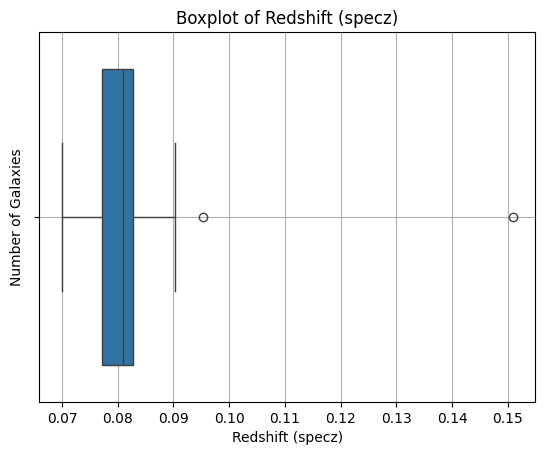

In [161]:
# Plot the dsitribution of redshift as boxplot 
import seaborn as sns
sns.boxplot(x=averaged_df['specz'])
plt.title('Boxplot of Redshift (specz)')
plt.ylabel('Number of Galaxies')
plt.xlabel('Redshift (specz)')
plt.grid(True)
plt.show()

This plot shows that most redshifts lie around the mean 0.0808.The spread is small (standard deviation ≈ 0.0086), so galaxies are closely clustered in redshift.

But the best plot would be a histogram to see where most of the objects downloaded lie in terms of redshift value

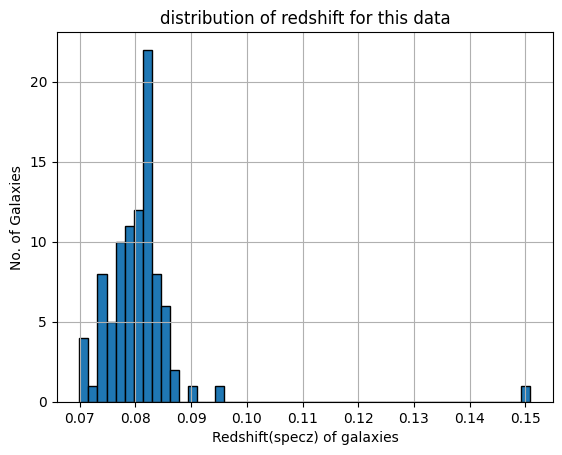

In [162]:
# Plot the dsitribution of redshift as histogram
plt.hist(averaged_df['specz'], bins=50, edgecolor='black')
plt.title("distribution of redshift for this data")
plt.xlabel('Redshift(specz) of galaxies')
plt.ylabel('No. of Galaxies')
plt.grid(True)
plt.show()

A high peak around 0.08 which means most galaxies are at that redshift.
Few bars away from center (at side of the peak) few galaxies far from cluster average.
This concludes that most galaxies in this dataset are physically close together forming a cluster.

Filter your data based on the 3-sigma limit of redshift. You should remove all data points which are 3-sigma away from mean of redshift

In [163]:
# Filtering the data based on specz values, used 3 sigma deviation from mean as upper limit.
filtered_df = averaged_df[(averaged_df['specz'] >= z_lower) & (averaged_df['specz'] <= z_upper)]

# Show how many galaxies are within the cluater acc to 3 sigma cut
print("Number of galaxies after 3-sigma filtering:", len(filtered_df))
filtered_df.head()

Number of galaxies after 3-sigma filtering: 91


,ra,dec,objid,specz,proj_sep,rmag,gmag
0,257.77059,64.052263,1.237670e+18,0.082759,9.716836,16.74029,17.65848
1,257.78072,64.082540,1.237670e+18,0.082786,9.162669,17.09841,18.06582
2,257.82458,64.133257,1.237670e+18,0.082457,8.347733,16.75003,17.49815
3,257.83332,64.126043,1.237670e+18,0.081218,8.011259,17.46793,18.38334
4,257.85137,64.173247,1.237670e+18,0.079564,8.739276,16.22043,17.18970


Use the relation between redshift and velocity to add a column named velocity in the data. This would tell the expansion velocity at that redshift 

In [164]:
filtered_df=filtered_df.copy()
c_kms = 3e5  # speed of light in km/s
filtered_df['velocity'] = c_kms * ((((1+averaged_df['specz'] )**2)-1) / (((1+averaged_df['specz'] )**2)+1))
filtered_df.head()

,ra,dec,objid,specz,proj_sep,rmag,gmag,velocity
0,257.77059,64.052263,1.237670e+18,0.082759,9.716836,16.74029,17.65848,23803.545455
1,257.78072,64.082540,1.237670e+18,0.082786,9.162669,17.09841,18.06582,23810.976388
2,257.82458,64.133257,1.237670e+18,0.082457,8.347733,16.75003,17.49815,23720.369898
3,257.83332,64.126043,1.237670e+18,0.081218,8.011259,17.46793,18.38334,23379.067626
4,257.85137,64.173247,1.237670e+18,0.079564,8.739276,16.22043,17.18970,22922.520537


The new column that just created shows how fast each galaxy is moving away from us due to the expansion of space, we calculated it using relativistic doppler formulae.https://resources.wolframcloud.com/FormulaRepository/resources/Relativistic-Redshift

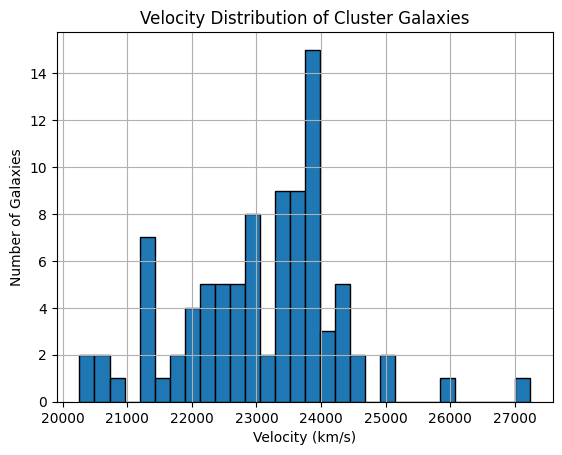

In [165]:
#plot the velocity column created as hist
plt.hist(filtered_df['velocity'], bins=30, edgecolor='black')
plt.title('Velocity Distribution of Cluster Galaxies')
plt.xlabel('Velocity (km/s)')
plt.ylabel('Number of Galaxies')
plt.grid(True)
plt.show()


This velocity distribution plot shows that as Most galaxies in the sample are moving away from Earth at 24,000 km/s due to the expansion of the universe

use the dispersion equation to find something called velocity dispersion. You can even refer to wikipedia to know about the term [wiki link here](https://en.wikipedia.org/wiki/Velocity_dispersion#:~:text=In%20astronomy%2C%20the%20velocity%20dispersion,%2C%20galaxy%20cluster%2C%20or%20supercluster.)

It is the velocity dispersion value which tells us, some galaxies might be part of even larger groups!!

In [166]:
# Calculate velocity dispersion (standard deviation)
disp = filtered_df['velocity'].std()
# Show 
print(f"Velocity Dispersion of the Cluster: {disp} km/s")

Velocity Dispersion of the Cluster: 1212.1246931097382 km/s


This velocity tells how fast galaxies are moving away from us due to the expansion of the universe.As it is no use in our calculation of dynamical mass as we only focus on the relative movement of galaxies inside the cluster, we will ignore this.

### Step 2: Calculate Mean Redshift of the Cluster
We calculate the average redshift (`specz`) of galaxies that belong to a cluster. This gives us an estimate of the cluster's systemic redshift.

`cluster_redshift = filtered_df['specz'].mean()`


The velocity dispersion \( v \) of galaxies relative to the cluster mean redshift is computed using the relativistic Doppler formula:

$$
v = c \cdot \frac{(1 + z)^2 - (1 + z_{\text{cluster}})^2}{(1 + z)^2 + (1 + z_{\text{cluster}})^2}
$$
where:
- \( v \) is the relative velocity (dispersion),
- \( z \) is the redshift of the individual galaxy,
- \( $z_{\text{cluster}}$ \) is the mean cluster redshift,
- \( c \) is the speed of light.


In [167]:
#Calculating average redshift of galaxies within the cluster
z_cluster=filtered_df['specz'].mean() 
c_kms = 3e5  # speed of light in km/s
filtered_df['velocity'] = c_kms * ((((1+filtered_df['specz'] )**2)-((1+z_cluster)**2)) / (((1+filtered_df['specz'] )**2)+((1+z_cluster)**2)))
#Show
filtered_df.head()

,ra,dec,objid,specz,proj_sep,rmag,gmag,velocity
0,257.77059,64.052263,1.237670e+18,0.082759,9.716836,16.74029,17.65848,746.524055
1,257.78072,64.082540,1.237670e+18,0.082786,9.162669,17.09841,18.06582,754.002034
2,257.82458,64.133257,1.237670e+18,0.082457,8.347733,16.75003,17.49815,662.823848
3,257.83332,64.126043,1.237670e+18,0.081218,8.011259,17.46793,18.38334,319.406316
4,257.85137,64.173247,1.237670e+18,0.079564,8.739276,16.22043,17.18970,-139.875806


The velocity column just added shows how fast the galaxy moving toward or away from the center of the cluster.This is the motion inside the cluster due to the galaxy’s position in the gravitational field of the cluster.

Pro tip: Check what the describe function of pandas does. Does it help to get quick look stats for your column of dispersion??

In [168]:
filtered_df['velocity'].describe() # It does help 

count      91.000000
mean       -2.451027
std      1219.336490
min     -2816.179091
25%      -807.165187
50%       237.343287
75%       755.500236
max      4209.048637
Name: velocity, dtype: float64

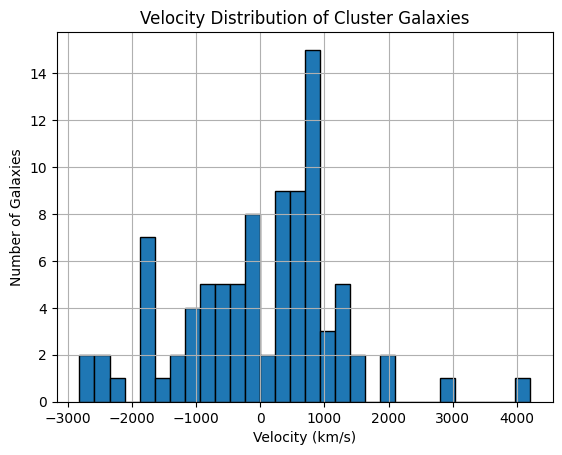

In [169]:
#plot the velocity column created as hist
plt.hist(filtered_df['velocity'], bins=30, edgecolor='black')
plt.title('Velocity Distribution of Cluster Galaxies')
plt.xlabel('Velocity (km/s)')
plt.ylabel('Number of Galaxies')
plt.grid(True)
plt.show()

According to our observation most galaxies are clustered in velocity around the cluster’s center motion as the peak of the bar graph is in 0

In [170]:
# show velocity dispersion
disp =filtered_df['velocity'].std()
print(f"The value of the cluster redshift = {z_cluster:.4}")
print(f"The characteristic value of velocity dispersion of the cluster along the line of sight = {disp:.4} km/s.")


The value of the cluster redshift = 0.08007
The characteristic value of velocity dispersion of the cluster along the line of sight = 1.219e+03 km/s.


Being the velocity dispersion the statistical dispersion of velocities about the mean velocity for a group of galaxies, this value shows that it is quite high which which makes sense because galaxy clusters are huge, and galaxies inside them can move at thousands of km/s 

### Step 3: Visualizing Angular Separation of Galaxies
We plot a histogram of the projected (angular) separation of galaxies from the cluster center. This helps us understand the spatial distribution of galaxies within the cluster field.

- The x-axis represents the angular separation (in arcminutes or degrees, depending on units).
- The y-axis shows the number of galaxies at each separation bin.



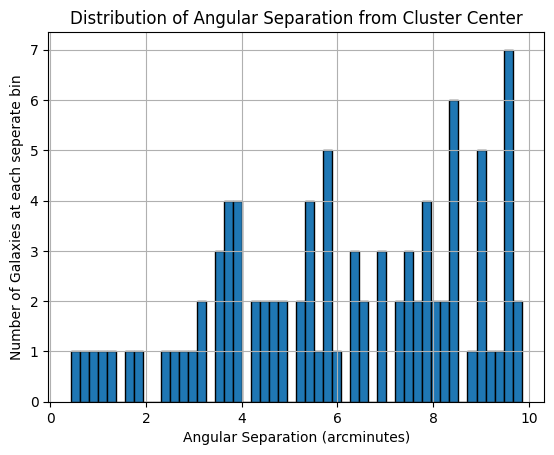

In [250]:
#plot histogram for proj sep column
plt.hist(filtered_df['proj_sep'], bins=50, edgecolor='black')
plt.title('Distribution of Angular Separation from Cluster Center')
plt.xlabel('Angular Separation (arcminutes)')
plt.ylabel('Number of Galaxies at each seperate bin')
plt.grid(True)
plt.show()

This graph shows that most of the galaxies resides within 10 arcminutes of angular seperation from centre of the cluster 

### Determining size and mass of the cluster:

### Step 4: Estimating Physical Diameter of the Cluster
We now estimate the **physical diameter** of the galaxy cluster using cosmological parameters.

- `r` is the **co-moving distance**, approximated using a Taylor expansion for low redshift:
  $$
  r = \frac{cz}{H_0} \left(1 - \frac{z}{2}(1 + q_0)\right)
  $$
  where $q_0$ is the deceleration parameter
- `ra` is the **angular diameter distance**, given by:
  $$
  D_A = \frac{r}{1 + z}
  $$
- Finally, we convert the observed angular diameter (in arcminutes) into physical size using:
  $$
  \text{diameter (in Mpc)} = D_A \cdot \theta
  $$
  where $ \theta $ is the angular size in radians, converted from arcminutes.

> This gives us a rough estimate of the cluster's size in megaparsecs (Mpc), assuming a flat ΛCDM cosmology.


In [251]:
import numpy as np
# Constants
c = 3e5  # speed of light in km/s
H0 = 70  # Hubble constant in km/s/Mpc 
q0 = 0.5  # Deceleration parameter for ΛCDM
# average redshift of the cluster
z_cluster = filtered_df['specz'].mean()
# co-moving distance 
r = (c * z_cluster / H0) * (1 - (z_cluster / 2) * (1 + q0))  # in Mpc
# angular diameter distance
DA = r / (1 + z_cluster)  # in Mpc
# max proj_sep as to know the the largest angular distance of a galaxy from the cluster center(arcminutes to radians)
theta_rad = (filtered_df['proj_sep'].max())*(np.pi /(180* 60))
# physical diameter for cluster
D_mpc = theta_rad*DA
# calculate radius
cluster_radius = D_mpc/2

# Show 
print(f"  Co-moving distance r = {r:.2f} Mpc")
print(f"  Angular diameter distance DA = {DA:.2f} Mpc")
print(f"  Estimated cluster radius = {cluster_radius:.2f} Mpc")
print(f"  Estimated cluster diameter = {D_mpc:.2f} Mpc")

  Co-moving distance r = 322.54 Mpc
  Angular diameter distance DA = 298.63 Mpc
  Estimated cluster radius = 0.43 Mpc
  Estimated cluster diameter = 0.86 Mpc


### Step 5: Calculating the Dynamical Mass of the Cluster
We now estimate the **dynamical mass** of the galaxy cluster using the virial theorem:

$$
M_{\text{dyn}} = \frac{3 \sigma^2 R}{G}
$$

Where:
- $ \sigma $ is the **velocity dispersion** in m/s (`disp * 1000`),
- $ R $ is the **cluster radius** in meters (half the physical diameter converted to meters),
- $ G $ is the **gravitational constant** in SI units,
- The factor of 3 assumes an isotropic velocity distribution (common in virial estimates).

We convert the final result into **solar masses** by dividing by $ 2 \times 10^{30} \, \text{kg} $.

> This mass estimate assumes the cluster is in dynamical equilibrium and bound by gravity.


In [281]:
# Calculating the dynamical mass in solar masses:
# Given:
disp =filtered_df['velocity'].std()        # velocity dispersion in km/s
diameter = 0.86  # physical diameter in Mpc
G = 6.67430e-11       # gravitational constant in m^3 kg^-1 s^-2
M_sun = 2e30          # mass of the Sun in kg

# Convert values to SI units:
disp_mps = disp * 1000                                 # km/s to m/s
radius_m = (diameter / 2) * 1e6 * 3.086e16             # Mpc to meters

# Apply virial theorem
M_dyn_kg = (3 * disp_mps**2 * radius_m) / G            # in kilograms
M_dyn_solar = M_dyn_kg / M_sun                         # convert to solar masses

# Print result
print(f"Dynamical Mass of the cluster is {M_dyn_solar:.2e} solar masses")

Dynamical Mass of the cluster is 4.43e+14 solar masses


### Step 6: Estimating Luminous Mass
We will step by step calculate Luminous mass but first we are calculating absolute mass using this Distance Modulus Formula.

$$
M = m - 5 \log_{10}(d / 10)
$$

Where:
- M: absolute magnitude
- m: apparent magnitude (rmag)
- d: luminosity distance in parsec

Information at https://en.wikipedia.org/wiki/Distance_modulus

In [229]:
from astropy.cosmology import Planck18 as cosmo
import numpy as np

# Get distance to each galaxy
filtered_df['luminosity_distance'] = cosmo.luminosity_distance(filtered_df['specz']).to('pc').value

# calculate absolute magnitude using distance modulus of each galaxy
filtered_df['abs_rmag'] = filtered_df['rmag'] - 5 * np.log10(filtered_df['luminosity_distance'] / 10)


Then we can calculate Luminosity using the formulae:

$$
L = 10^{0.4(M_\odot - M)}
$$

- $M_\odot$:Sun's r band absolute magnitude
- $L$: Luminosity
- $M$: Galaxy's r-band absolute magnitude

Information at https://en.wikipedia.org/wiki/Absolute_magnitude

In [296]:
M_sun = 4.83  # Sun's absolute magnitude in r-band(reference from https://en.wikipedia.org/wiki/Absolute_magnitude)

# Convert absolute magnitude to luminosity of each galaxy
filtered_df['luminosity'] = 10 ** (-0.4 * (filtered_df['abs_rmag']-M_sun  ))

Then we calculate the M\L ratio using g-r formula:

$$
\log_{10}\left(\frac{M}{L}\right) = -0.306 + 1.097 (g - r)
$$


Information at https://arxiv.org/pdf/2411.14885

In [297]:
# Calculate M/L ratio 
filtered_df['g_minus_r'] = filtered_df['gmag'] - filtered_df['rmag']
filtered_df['logML_ratio'] = -0.306 + 1.097 * filtered_df['g_minus_r']
filtered_df['ML_ratio'] = 10 ** filtered_df['logML_ratio']



Finally using M/L ratio , we get the Luminous mass for the cluster.

$$
Luminous  Mass = L \times \frac{M}{L}
$$

Information at https://en.wikipedia.org/wiki/Mass-to-light_ratio

In [295]:
# Multiply luminosity by M/L ratio
filtered_df['luminous_mass'] = filtered_df['luminosity'] * filtered_df['ML_ratio']
# Sum up all galaxy luminous masses
total_luminous_mass = filtered_df['luminous_mass'].sum()
print(f"Total Luminous Mass of Cluster: {total_luminous_mass:.2e} M_sun")

Total Luminous Mass of Cluster: 1.31e+13 M_sun


 I have also tried a different way to calculate the physical diameter of the cluster. By calculating the centre of the cluster using mean of ra dec and calculating DA using the Astropy's cosmology model.(Reference from https://astronomy.stackexchange.com/questions/18713/centre-projected-of-a-galaxy-cluster) 

In [277]:
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np

# Calculate mean RA and Dec of the cluster (from filtered cluster galaxies)
cluster_ra = filtered_df['ra'].mean()
cluster_dec = filtered_df['dec'].mean()
print(f"Cluster Center (mean): RA = {cluster_ra:.5f}, Dec = {cluster_dec:.5f}")

# Define the cluster center and galaxy positions
cluster_center = SkyCoord(cluster_ra, cluster_dec, unit='deg')
galaxy = SkyCoord(filtered_df['ra'], filtered_df['dec'], unit='deg')

# Calculate angular separations in degrees and arcminutes
ang_sep = galaxy.separation(cluster_center)
filtered_df['ang_sep_deg'] = ang_sep.deg
filtered_df['ang_sep_arcmin'] = ang_sep.arcminute



Cluster Center (mean): RA = 258.16072, Dec = 64.07383


In [280]:
# Constants
c = 3e5  # km/s
H0 = 70  # km/s/Mpc
q0 = 0.5  # deceleration parameter
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

# Mean cluster redshift
z_cluster = filtered_df['specz'].mean()

# Angular diameter distance from cosmological model
DA = cosmo.angular_diameter_distance(z_cluster).to(u.Mpc)

#  max angular separation and then convert to radians
theta_arcmin = filtered_df['ang_sep_arcmin'].max()
theta_rad = np.radians(theta_arcmin / 60)
# calculate diameter and radius
diameter_mpc = DA * theta_rad
cluster_radius = diameter_mpc/2
# Output
print(f"  Co-moving distance, r = {r:.2f} Mpc")
print(f"  Angular diameter distance, DA : {DA:.2f} ")
print(f"  Estimated cluster radius = {cluster_radius:.2f} ")
print(f"  Estimated cluster diameter = {diameter_mpc:.2f} ")


  Co-moving distance, r = 322.54 Mpc
  Angular diameter distance, DA : 322.24 Mpc 
  Estimated cluster radius = 0.48 Mpc 
  Estimated cluster diameter = 0.97 Mpc 


In [283]:
# Calculating the dynamical mass in solar masses:
# Given:
disp =filtered_df['velocity'].std()        # velocity dispersion in km/s
diameter = 0.97 # physical diameter in Mpc
G = 6.67430e-11       # gravitational constant in m^3 kg^-1 s^-2
M_sun = 2e30          # mass of the Sun in kg

# Convert values to SI units:
disp_mps = disp * 1000                                 # km/s to m/s
radius_m = (diameter / 2) * 1e6 * 3.086e16             # Mpc to meters

# Apply virial theorem
M_dyn_kg = (3 * disp_mps**2 * radius_m) / G            # in kilograms
M_dyn_solar = M_dyn_kg / M_sun                         # convert to solar masses

# Print result
print(f"Dynamical Mass of the cluster is {M_dyn_solar:.2e} solar masses")

Dynamical Mass of the cluster is 5.00e+14 solar masses


Comparing it to luminous mass, we can see that luminous mass is only about 2.62% of this dynamical mass which is almost near to the result from dynamical mass estimated earlier.Hence this is also consistent with the theory of galaxy cluster that most of the dynamical mass of galaxy cluster consists of dark matter.

## Answer to the questions asked in the project guide.

### (1)	Identify galaxies that you think are members of a cluster.

- To identify galaxies that are members of the cluster, we calculated the mean redshift and standard deviation of the full redshift dataset. We then applied a statistical filter by selecting only those galaxies whose redshifts fell within three standard deviations (3σ) of the mean redshift. This 3σ cut is a method which helps exclude foreground and background galaxies while retaining the core cluster members. Although redshift can be converted into velocity, we directly applied the 3σ cut in redshift space for simplicity, since redshift is the observation, we had.


  Lower limit = Mean - 3 x standard deviation


  Upper Limit  = Mean + 3 x standard deviation


  From our observation, the Lower limit and Upper limit are found to be 0.05 and 0. 106.Any galaxy beyond the range are assumed to not to be part of the cluster

### (2)	After the required analysis of the table of data, determine the cluster redshift, and obtain an estimate for the characteristic velocity dispersion of galaxies that belong to the cluster in units of km/s.

- We calculated the mean redshift of these selected galaxies for cluster (after 3 σ filtering), which gave accurate estimate of the cluster's redshift.


  To determine the velocity dispersion, we converted each galaxy’s redshift into its corresponding velocity using relativistic Doppler formula. 

  $$
  v = c \cdot \frac{(1 + z)^2 - (1 + z_{\text{cluster}})^2}{(1 + z)^2 + (1 + z_{\text{cluster}})^2}
  $$  
                                                                                                            
  This changing into velocity simplified our work for estimating the internal motions within the cluster due to gravitational interactions. We then computed the standard deviation (σ) of these velocities, which represents the velocity dispersion of the cluster which shows how fast galaxies are moving relative to the cluster’s mean redshift. 

  We found velocity dispersion to be 1219 km/s.

### (3)	Estimate the characteristic size of the cluster in Mpc.

- To estimate the characteristic size of the galaxy cluster in megaparsecs (Mpc), we used the projected angular separations of each galaxy from the cluster centre, provided in the dataset as the proj_sep column in arcminutes.
 

  We first took the maximum proj_sep, so that we get the largest angular distance of a galaxy from the cluster center and then turn this value into angular sizes in radians using the relation θ=proj_sep×(π/180×60).


  Then, using the mean redshift of the galaxy within the cluster, we calculated the angular diameter distance. Then we compute the projected physical distance for each galaxy using the formula D=DA.θ. This value was then used to compute the projected diameter, and dividing it by two gave the characteristic radius of the cluster in Mpc.


  We found the characteristic size of the cluster to be 0.86 Mpc.






### (4)	Estimate the dynamical mass of the cluster and quote the value in units of solar mass.

- To estimate the dynamical mass of the galaxy cluster, we applied the virial theorem.
                                                                                                                                                                                                  
  $$
  M_{\text{dyn}} = \frac{3 \sigma^2 R}{G}
  $$                                                                                                                                                                                                

  Earlier steps, we calculated the velocity dispersion σv  of the cluster using the redshifts .We also previously estimated the characteristic size of the cluster in megaparsecs (Mpc) using the projected angular separation method and redshifts. 
  

  With these two key quantities σv converted to m/s and radius(half of the size/diameter)converted from Mpc to meters , we used the virial mass formula. We got the dynamical mass in SI units and then dividing it by 2 * 10^30 kg ,we got it in solar masses We observed our dynamical mass of the cluster to be 4.34*10^14 solar masses.

### (5)	Is the estimate of dynamical mass consistent with what is expected from the luminous mass? If not, explain with the support of numbers the inconsistency.

- Luminous mass is the mass only which emits light in the clusters which are basically the stars present around the galaxies within the cluster. Hence, we can say we are sort of calculating the stellar mass of the cluster.


  To estimate the total luminous mass of the cluster, we first calculated the luminosity distance to each galaxy using the Planck18 cosmology from the astropy.cosmology module. 
                                                                                                                                                                                                  
  Then, we then applied the distance modulus formula to convert each galaxy’s apparent r-band magnitude into its absolute magnitude. Using the absolute magnitude, we calculated each galaxy’s luminosity relative to the Sun, assuming the Sun's r-band absolute magnitude is 4.83.
  we estimated each galaxy’s mass-to-light (M/L) ratio based on its color index using a logarithmic relation (The formulas are in the code). 
                                                                                                                                                                                                  
  Then computed each galaxy’s luminous mass by multiplying its luminosity by its M/L ratio.Then summed up all the luminous mass of each galaxy to get our needed result which was the luminous mass of the cluster:1.31 * 10^13 solar masses                                                                                                                                                                                             
  
                                                                                                                                                                                                  
  Our dynamical mass was found 4.34 * 10^14 solar masses. When comparing it with luminous mass, the luminous is only about 2.95 % of the dynamical mass. 


  As we know Galaxy Clusters consist of galaxies, heated gas, and dark matter consisting of 1%,9% and 90% of its dynamical mass.


  I think our observation is quite consistent as our results strongly support the presence of dark matter as the dominant mass component of the galaxy cluster.
  (reference from https://en.wikipedia.org/wiki/Galaxy_cluster)

                                                                                                                                                                                               
                                                                                                                                                                                               
                                                                                                                                                                                               



<center><h3>PLOTS</h3></center>

### Redshift Histogram

This histogram displays the distribution of redshifts for all galaxies in the field.There’s a clear peak around z≈0.08.The peak suggests a concentration of galaxies at similar distances, indicating the presence of a galaxy cluster.It also helps define redshift limits for selecting member galaxies using a 3σ cut.The green line shows the limits of redshifts. The galaxy within this limits of redshifts are the members of galaxy. The red line shows the mean redshift, more no. of galaxies have that redshift. 

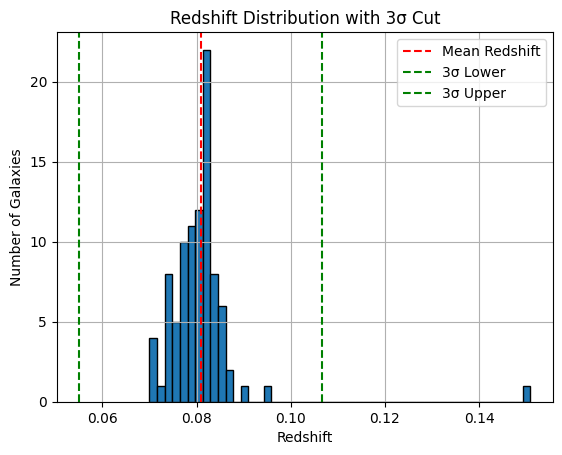

In [300]:
plt.hist(averaged_df['specz'], bins=50, edgecolor='black')
plt.axvline(mean_z, color='red', linestyle='--', label='Mean Redshift')
plt.axvline(z_lower, color='green', linestyle='--', label='3σ Lower')
plt.axvline(z_upper, color='green', linestyle='--', label='3σ Upper')
plt.title("Redshift Distribution with 3σ Cut")
plt.xlabel("Redshift")
plt.ylabel("Number of Galaxies")
plt.legend()
plt.grid(True)
plt.show()


###  Velocity Histogram

This plot shows the distribution of galaxy velocities relative to the cluster's average motion.
The histogram is roughly centered around 0 km/s.
This says that most galaxies are gravitationally bound to the cluster, moving randomly about the cluster’s center.
The spread (standard deviation) of this plot gives the velocity dispersion 
The red dotted line hows the cluster center.
 



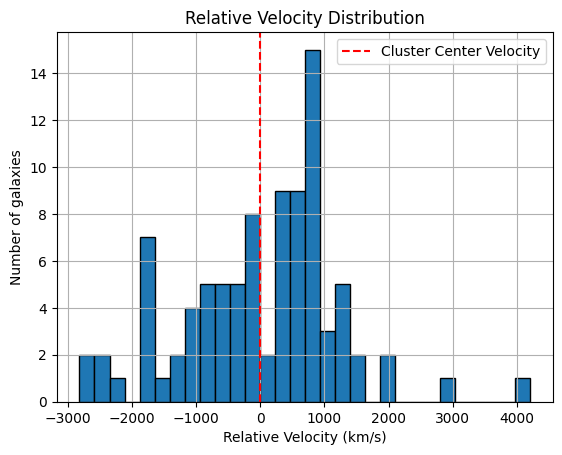

In [291]:
plt.hist(filtered_df['velocity'], bins=30, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='Cluster Center Velocity')
plt.title('Relative Velocity Distribution')
plt.xlabel('Relative Velocity (km/s)')
plt.ylabel('Number of galaxies')
plt.legend()
plt.grid(True)
plt.show()


### Histogram of Projected Angular Separation (proj_sep)
This plot shows how far each galaxy is, in angular terms, from the cluster center (in arcminutes).
The maximum value of proj_sep gives the largest observed extent of the cluster in projection.
Converting this to a physical distance helps estimate the diameter of the cluster in Mpccan be used in the virial formula for mass calculation.
Most galaxies fall within 10 arcminutes which can mean most of the galaxies are concentrated close to the cluster center on the sky.

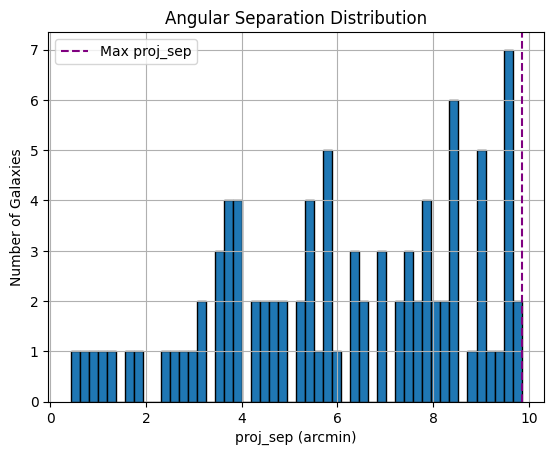

In [289]:
plt.hist(filtered_df['proj_sep'], bins=50, edgecolor='black')
plt.axvline(filtered_df['proj_sep'].max(), color='purple', linestyle='--', label='Max proj_sep')
plt.title("Angular Separation Distribution")
plt.xlabel("proj_sep (arcmin)")
plt.ylabel("Number of Galaxies")
plt.legend()
plt.grid(True)
plt.show()


## Conclusion

### (SUMMARY OF OBSERVATION AND INTERPRETATION)
- In this project, we used spectroscopic data from SDSS given to us to identify and analyze a galaxy cluster. By examining the redshift distribution, we found a clear peak at z=0.08, indicating the presence of a cluster. Using a 3σ cut around the mean redshift, we identified 91 galaxies likely to be cluster member galaxies. These galaxies exhibited velocities that clustered closely around the systemic cluster motion, with a velocity dispersion of approximately 1219 km/s, consistent with typical galaxy cluster dynamics.
- We estimated the cluster’s physical size using the maximum projected angular separation of its members, converted to a radius of approximately 0.43 Mpc. Then applying the virial theorem, we derived the dynamical mass of the cluster to be about 
  4.43×10^14 solar masses.
- In contrast, the total luminous mass calculated from galaxy magnitudes,colors,and the theory of luminosity, distance modulus and M/L ratio was found to be only 1.31×10^13 solar masses.
- This large difference where the luminous mass is only 2.95% times of the dynamical mass tells us the presence of dark matter within the cluster which have no role in luminous mass.
  Our results are consistent with current understanding of galaxy clusters that they are dark matter-dominated systems. The analysis of redshift, velocity distribution, and angular separation not only helped in identifying the cluster but also in quantifying the cluster mass. Overall, the project demonstrates how observable properties like redshift(z), projected angular seperation(proj_sep) and brightness(rmag,gmag,umag) can be used to infer fundamental characteristics of large astronomical structures which are very larger than sun.  



### References:
- https://en.wikipedia.org/wiki/Galaxy_cluster
- https://resources.wolframcloud.com/FormulaRepository/resources/Relativistic-Redshift
- https://en.wikipedia.org/wiki/Velocity_dispersion#:~:text=In%20astronomy%2C%20the%20velocity%20dispersion,%2C%20galaxy%20cluster%2C%20or%20supercluster.
- https://astronomy.stackexchange.com/questions/18713/centre-projected-of-a-galaxy-cluster
- https://ned.ipac.caltech.edu/level5/Faber/Faber7_1.html#:~:text=Once%20RVT%20has%20been,V2%20RVT%20%2F%20G.
- https://en.wikipedia.org/wiki/Redshift


Other references are added inside the code..

 